# Проверяем, влияет ли тип мутации KRAS + уровень экспрессии KRAS на то, насколько сильно клетка теряет жизнеспособность после knockout KRAS.

In [8]:
import pandas as pd 

KRAS_data = pd.read_csv("KRAS_data.csv")
print(KRAS_data.shape)
KRAS_data

(46, 6)


,ModelID,KRAS_GeneEffect,KRAS_expression,KRAS_protein_changes,KRAS_hotspot,PatientID
0,ACH-000552,-0.468224,4.958708,NaN,0,PT-sF39aT
1,ACH-000958,-0.526112,4.672029,NaN,0,PT-EB6qeM
2,ACH-001061,-1.514492,5.191002,p.G13D,1,PT-i0VYNQ
3,ACH-002669,-0.349134,4.760817,NaN,0,PT-53ZOQS
4,ACH-000403,-2.140278,4.167262,p.G13D,1,PT-cabct5
5,ACH-000959,-1.018418,4.796784,NaN,0,PT-ulmNPq
6,ACH-000986,-1.145164,4.704789,NaN,0,PT-EoHcfh
7,ACH-000943,-0.521471,4.409235,NaN,0,PT-9E5O4L
8,ACH-000963,-0.746334,4.679277,NaN,0,PT-c4ZGOD
9,ACH-001399,-3.237185,5.129032,p.G12V,1,PT-V8yAFO


In [ ]:
# Мы значем о том что есть две MODELID полученных от одного и того же пациента.
KRAS_data[KRAS_data['PatientID'].duplicated(keep=False)].sort_values('PatientID')

,ModelID,KRAS_GeneEffect,KRAS_expression,KRAS_protein_changes,KRAS_hotspot,PatientID
2,ACH-001061,-1.514492,5.191002,p.G13D,1,PT-i0VYNQ
38,ACH-000997,-0.699265,5.221208,p.G13D,1,PT-i0VYNQ


In [13]:
cond_1 = (KRAS_data["KRAS_hotspot"] == 1)

display("with hotspot:", KRAS_data.loc[cond_1]['KRAS_GeneEffect'].describe())
display("without hotspot:", KRAS_data.loc[~cond_1]['KRAS_GeneEffect'].describe())

'with hotspot:'

count    23.000000
mean     -1.951581
std       0.730169
min      -3.237185
25%      -2.521762
50%      -1.949217
75%      -1.441274
max      -0.699265
Name: KRAS_GeneEffect, dtype: float64

'without hotspot:'

count    23.000000
mean     -0.715637
std       0.386795
min      -1.558605
25%      -0.993873
50%      -0.711538
75%      -0.494847
max       0.025491
Name: KRAS_GeneEffect, dtype: float64

In [14]:
with_hotspot = KRAS_data.loc[
    KRAS_data["KRAS_hotspot"].eq(1),
    "KRAS_GeneEffect"
].dropna()
print(len(with_hotspot))

without_hotspot = KRAS_data.loc[
    KRAS_data["KRAS_hotspot"].eq(0),
    "KRAS_GeneEffect"
].dropna()
print(len(without_hotspot))


23
23


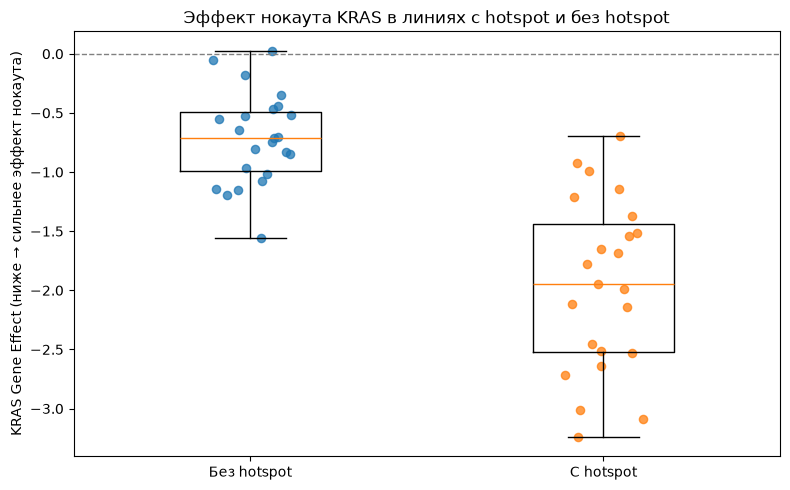

In [16]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
fig, ax = plt.subplots(figsize=(8, 5))
arrays = [without_hotspot.to_numpy(), with_hotspot.to_numpy()]
ax.boxplot(arrays, positions=[0, 1], widths=0.4, showfliers=False)
for position, values in enumerate(arrays):
    ax.scatter(position + rng.uniform(-0.12, 0.12, len(values)), values,
               alpha=0.75, s=35)
ax.set_xticks([0, 1], ["Без hotspot", "С hotspot"])
ax.set_ylabel("KRAS Gene Effect (ниже → сильнее эффект нокаута)")
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Эффект нокаута KRAS в линиях с hotspot и без hotspot")
fig.tight_layout()
plt.show()

In [22]:
from scipy import stats

result = stats.ttest_ind(
    with_hotspot,
    without_hotspot,
    equal_var=False
)

print("t-статистика:", result.statistic)
print(f"p-value: {result.pvalue:.12f}")

t-статистика: -7.1734703881937545
p-value: 0.000000029628


В исследованных линиях с hotspot KRAS средний эффект его нокаута более отрицательный, чем в линиях без hotspot. Тест Уэлча поддерживает статистическую значимость этого различия.

# Связана ли экспрессия KRAS с эффектом его нокаута.

In [24]:
KRAS_data.head()

,ModelID,KRAS_GeneEffect,KRAS_expression,KRAS_protein_changes,KRAS_hotspot,PatientID
0,ACH-000552,-0.468224,4.958708,NaN,0,PT-sF39aT
1,ACH-000958,-0.526112,4.672029,NaN,0,PT-EB6qeM
2,ACH-001061,-1.514492,5.191002,p.G13D,1,PT-i0VYNQ
3,ACH-002669,-0.349134,4.760817,NaN,0,PT-53ZOQS
4,ACH-000403,-2.140278,4.167262,p.G13D,1,PT-cabct5


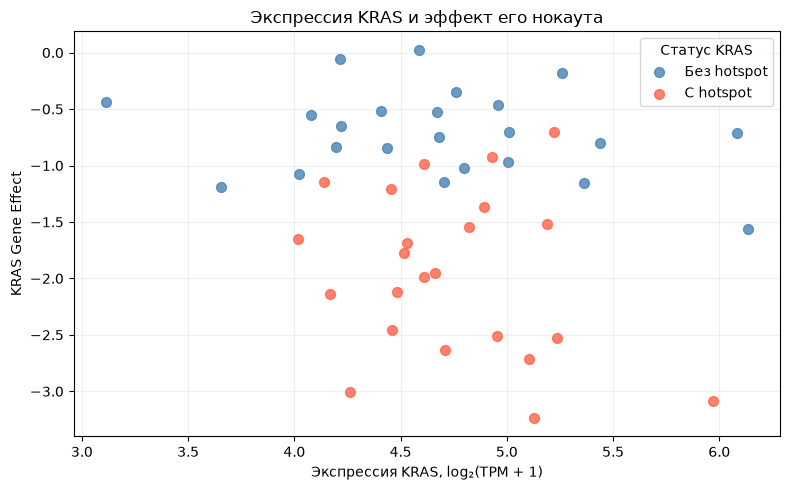

Hotspot=0: n=23, корреляция=-0.172, p-value=0.4328
Hotspot=1: n=23, корреляция=-0.166, p-value=0.4490


In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

for hotspot, color, label in [
    (0, "steelblue", "Без hotspot"),
    (1, "tomato", "С hotspot"),
]:
    group = KRAS_data.loc[KRAS_data["KRAS_hotspot"].eq(hotspot)]

    ax.scatter(
        group["KRAS_expression"],
        group["KRAS_GeneEffect"],
        color=color,
        label=label,
        alpha=0.8,
        s=50,
    )

ax.set_xlabel("Экспрессия KRAS, log₂(TPM + 1)")
ax.set_ylabel("KRAS Gene Effect")
ax.set_title("Экспрессия KRAS и эффект его нокаута")
ax.legend(title="Статус KRAS")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


from scipy.stats import spearmanr

for hotspot in [0, 1]:
    group = KRAS_data.loc[
        KRAS_data["KRAS_hotspot"].eq(hotspot),
        ["KRAS_expression", "KRAS_GeneEffect"]
    ].dropna()

    rho, p = spearmanr(
        group["KRAS_expression"],
        group["KRAS_GeneEffect"]
    )

    print(
        f"Hotspot={hotspot}: n={len(group)}, "
        f"корреляция={rho:.3f}, p-value={p:.4f}"
    )

Из графа видно что уровень эксперсесии РНК не свзяан с эффектом его нокаута

# Cравнить на отложенных линиях два прогноза: только по hotspot и по hotspot вместе с экспрессией.

In [31]:
KRAS_data.head()

,ModelID,KRAS_GeneEffect,KRAS_expression,KRAS_protein_changes,KRAS_hotspot,PatientID
0,ACH-000552,-0.468224,4.958708,NaN,0,PT-sF39aT
1,ACH-000958,-0.526112,4.672029,NaN,0,PT-EB6qeM
2,ACH-001061,-1.514492,5.191002,p.G13D,1,PT-i0VYNQ
3,ACH-002669,-0.349134,4.760817,NaN,0,PT-53ZOQS
4,ACH-000403,-2.140278,4.167262,p.G13D,1,PT-cabct5


In [ ]:
import numpy as np
from pprint import pprint

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Все способы сравниваем на одних и тех же строках
data = KRAS_data.dropna(
    subset=["KRAS_hotspot", "KRAS_expression", "KRAS_GeneEffect"]
).reset_index(drop=True)

y = data["KRAS_GeneEffect"]

# Если PatientID неизвестен, временно считаем модель отдельной группой
groups = data["PatientID"].fillna(data["ModelID"])

# Фиксируем одинаковые разбиения для всех способов
cv = GroupKFold(n_splits=5)
splits = list(cv.split(data, y, groups=groups))
pprint(splits)

Проверка 1
  Обучение: 36 линий
  Проверка: 10 линий
Проверка 2
  Обучение: 37 линий
  Проверка: 9 линий
Проверка 3
  Обучение: 37 линий
  Проверка: 9 линий
Проверка 4
  Обучение: 37 линий
  Проверка: 9 линий
Проверка 5
  Обучение: 37 линий
  Проверка: 9 линий


In [34]:
methods = {
    "Среднее для всех": (
        DummyRegressor(strategy="mean"),
        ["KRAS_hotspot"],
    ),
    "Только hotspot": (
        LinearRegression(),
        ["KRAS_hotspot"],
    ),
    "Hotspot + экспрессия": (
        LinearRegression(),
        ["KRAS_hotspot", "KRAS_expression"],
    ),
}

predictions = {}
results = []

for name, (model, columns) in methods.items():
    prediction = cross_val_predict(
        model,
        data[columns],
        y,
        cv=splits,
    )

    predictions[name] = prediction

    results.append({
        "Способ": name,
        "MAE": mean_absolute_error(y, prediction),
        "RMSE": np.sqrt(mean_squared_error(y, prediction)),
    })

results = pd.DataFrame(results).set_index("Способ")
display(results)

,MAE,RMSE
Способ,,
Среднее для всех,0.719543,0.864034
Только hotspot,0.506735,0.627270
Hotspot + экспрессия,0.504995,0.630737


# KRAS_data_EXPANDED

In [3]:
import pandas as pd
KRAS_data_exp = pd.read_csv("/Users/nident/Desktop/JOB/Cancer Cell Line Encyclopedia (CCLE)/data/pilot/KRAS_data_expanded.csv")
print(KRAS_data_exp.shape)
KRAS_data_exp.head()

(46, 12)


,ModelID,KRAS_GeneEffect,KRAS_expression,KRAS_protein_changes,KRAS_hotspot,PatientID,CellLineName,PrimaryOrMetastasis,SampleCollectionSite,Age,Sex,GrowthPattern
0,ACH-000552,-0.468224,4.958708,NaN,0,PT-sF39aT,HT-29,Primary,large_intestine,44.0,Female,Adherent
1,ACH-000958,-0.526112,4.672029,NaN,0,PT-EB6qeM,SW48,Primary,Colon,83.0,Female,Mixed
2,ACH-001061,-1.514492,5.191002,p.G13D,1,PT-i0VYNQ,DLD-1,Primary,large_intestine,67.0,Male,Adherent
3,ACH-002669,-0.349134,4.760817,NaN,0,PT-53ZOQS,KP-363T,Primary,Colon,80.0,Male,Adherent
4,ACH-000403,-2.140278,4.167262,p.G13D,1,PT-cabct5,NCI-H747,Metastatic,large_intestine,69.0,Male,Adherent
